generate_classification took 0.0014 seconds


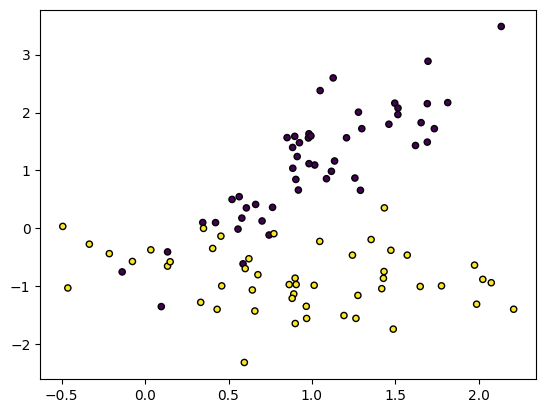

In [61]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

import time

def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"{func.__name__} took {end - start:.4f} seconds")
        return result
    return wrapper 

@timer

def generate_classification(seed):
    X, y = make_classification(n_features=2, n_redundant=0, random_state=seed, n_informative=2, n_clusters_per_class=1, n_classes=2,flip_y=0, shuffle=False) # n_features: total number of features, n_redundant: number of features generated as random linear combinations of the informative features, n_informative: number of features that are actually used to build the class labels, n_clusters_per_class: number of ways to cluster the class labels, n_classes: number of classes, flip_y: fraction of samples whose class is assigned randomly, shuffle: whether to shuffle the samples and features

    return X, y

X, y = generate_classification(seed=118)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20, cmap='viridis') # c: color, edgecolor: color of the edge of the points, s: size of the points, cmap: color map that maps the c values to colors
plt.show()

In [62]:
# @timer

def evaluate_cuts(threshold_x, threshold_y, X, y):
    
    acc = np.zeros(4)

    cuts_x = X[:, 0] > threshold_x
    cuts_y = X[:, 1] > threshold_y
    labels = np.where(cuts_x & cuts_y, 0, 1) # np.where(condition, x, y): condition: array-like, x: value to return where condition is True, y: value to return where condition is False; in this case, we want to return the true labels (y) where the cuts are satisfied (cuts_x & cuts_y), and 0 otherwise
    acc[0] = accuracy_score(y, labels) # accuracy_score(y_true, y_pred): y_true: true labels, y_pred: predicted labels; in this case, we want to compare the true labels (y) with the predicted labels (labels) to calculate the accuracy

    cuts_x = X[:, 0] < threshold_x 
    cuts_y = X[:, 1] < threshold_y
    labels = np.where(cuts_x & cuts_y, 0, 1)
    acc[1] = accuracy_score(y, labels)

    cuts_x = X[:, 0] > threshold_x
    cuts_y = X[:, 1] < threshold_y
    labels = np.where(cuts_x & cuts_y, 0, 1)
    acc[2] = accuracy_score(y, labels)

    cuts_x = X[:, 0] < threshold_x
    cuts_y = X[:, 1] > threshold_y
    labels = np.where(cuts_x & cuts_y, 0, 1)
    acc[3] = accuracy_score(y, labels)

    return np.max(acc)

In [71]:
# %%time

best_score = 0
best_thresholds = (0, 0)

for tx in np.linspace(X[:, 0].min(), X[:, 0].max(), 100):
    for ty in np.linspace(X[:, 1].min(), X[:, 1].max(), 100):
        score = evaluate_cuts(tx, ty, X, y)
        if score > best_score:
            best_score = score
            print(f"New best score: {best_score:.2f}")
            best_thresholds = (tx, ty)

New best score: 0.52
New best score: 0.53
New best score: 0.54
New best score: 0.56
New best score: 0.57
New best score: 0.60
New best score: 0.62
New best score: 0.63
New best score: 0.64
New best score: 0.65
New best score: 0.68
New best score: 0.74
New best score: 0.75
New best score: 0.78
New best score: 0.79
New best score: 0.80
New best score: 0.82
New best score: 0.83
New best score: 0.84
New best score: 0.86
New best score: 0.89
New best score: 0.90
New best score: 0.91
New best score: 0.92
New best score: 0.93
CPU times: user 16.5 s, sys: 63 ms, total: 16.5 s
Wall time: 16.6 s


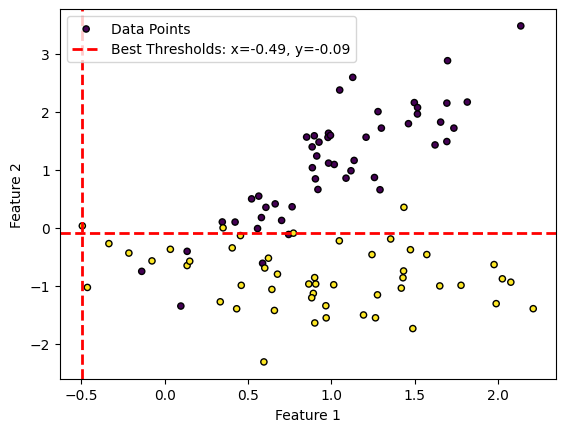

In [80]:
threshold_x, threshold_y = best_thresholds

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axvline(x=threshold_x, color='red', linestyle='--', linewidth=2)
plt.axhline(y=threshold_y, color='red', linestyle='--', linewidth=2)
plt.legend(loc='best', labels=['Data Points', f'Best Thresholds: x={threshold_x:.2f}, y={threshold_y:.2f}']) 
plt.show()